In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

# 1. SETUP PATHS
BASE_DIR = Path("..") 
RAW_DATA_DIR = BASE_DIR / "data" / "raw" / "ednet_kt1"
PROCESSED_DATA_DIR = BASE_DIR / "data" / "processed"
FIGURES_DIR = BASE_DIR / "report" / "figures"

# Create folders if they don't exist
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# 2. CONFIGURATION (The "Large Scale" setting)
N_USERS = 50000  # Set this to 50,000 for the experiment

In [2]:
# Check if directory exists
if not RAW_DATA_DIR.exists():
    print(f"ERROR: Directory not found at {RAW_DATA_DIR}")
else:
    # Use iterdir for speed on 700k files
    print("Counting total available files... (this may take a few seconds)")
    total_files = sum(1 for _ in RAW_DATA_DIR.iterdir())
    print(f"Total files in EdNet-KT1: {total_files:,}")
    print(f"Experiment Sample Size: {N_USERS:,} students ({(N_USERS/total_files)*100:.2f}% of dataset)")

Counting total available files... (this may take a few seconds)
Total files in EdNet-KT1: 784,309
Experiment Sample Size: 50,000 students (6.38% of dataset)


In [3]:
# Get the list of files to process
all_files = list(RAW_DATA_DIR.glob("*.csv"))
files_to_process = all_files[:N_USERS]

student_summaries = []
start_time = time.time()

print(f"Starting processing for {N_USERS:,} students...")

for file in tqdm(files_to_process, desc="Processing Students"):
    # Read individual CSV
    df = pd.read_csv(file)
    
    # Calculate features for THIS student only
    summary = {
        "user_id": file.stem,
        "total_questions": len(df),
        "avg_time_spent": df["elapsed_time"].mean(),
        "total_sessions": df["solving_id"].nunique(),
        "most_common_answer": df["user_answer"].mode().iloc[0] if not df["user_answer"].mode().empty else np.nan
    }
    student_summaries.append(summary)

# Convert results to a DataFrame
student_features = pd.DataFrame(student_summaries)

end_time = time.time()
duration = end_time - start_time
print(f"\nExperiment Complete!")
print(f"Total Processing Time: {duration:.2f} seconds")
print(f"Processing Speed: {len(files_to_process)/duration:.2f} students/sec")

Starting processing for 50,000 students...


Processing Students: 100%|██████████| 50000/50000 [02:58<00:00, 280.14it/s]


Experiment Complete!
Total Processing Time: 178.54 seconds
Processing Speed: 280.05 students/sec


In [4]:
# Calculate the "Big Data" metric
total_rows_handled = student_features['total_questions'].sum()

print("--- SCALE REPORT ---")
print(f"Total Student Profiles Created: {len(student_features):,}")
print(f"Total Raw Interaction Rows Analyzed: {total_rows_handled:,}")

# Save the resulting feature matrix
output_path = PROCESSED_DATA_DIR / "ednet_large_experiment_features.csv"
student_features.to_csv(output_path, index=False)
print(f"Results saved to: {output_path}")

student_features.head()

--- SCALE REPORT ---
Total Student Profiles Created: 50,000
Total Raw Interaction Rows Analyzed: 12,423,438
Results saved to: ..\data\processed\ednet_large_experiment_features.csv


,user_id,total_questions,avg_time_spent,total_sessions,most_common_answer
0,u1,1082,49578.441774,671,b
1,u10,16,29125.000000,13,a
2,u100,33,33151.484848,23,c
3,u1000,1488,41128.524194,977,b
4,u10000,405,36254.320988,402,a


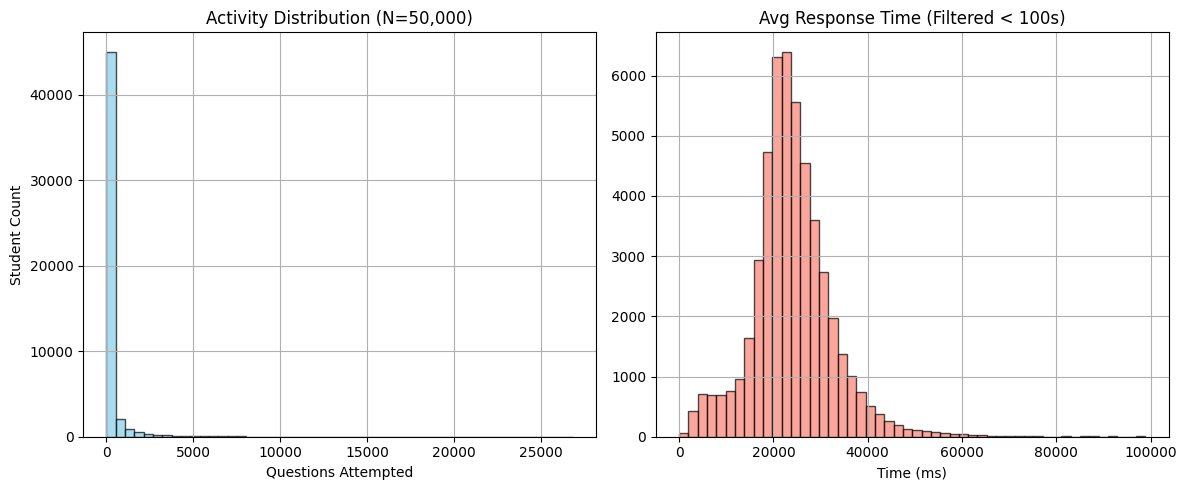

In [5]:
# Create Activity Histogram
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
student_features["total_questions"].hist(bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.title(f"Activity Distribution (N={N_USERS:,})")
plt.xlabel("Questions Attempted")
plt.ylabel("Student Count")

# Create Time Spent Histogram
plt.subplot(1, 2, 2)
# We filter out extreme outliers (> 100,000ms) for a cleaner visual
filtered_time = student_features[student_features["avg_time_spent"] < 100000]["avg_time_spent"]
filtered_time.hist(bins=50, color='salmon', edgecolor='black', alpha=0.7)
plt.title("Avg Response Time (Filtered < 100s)")
plt.xlabel("Time (ms)")

plt.tight_layout()

# Save figures
plt.savefig(FIGURES_DIR / "large_experiment_results.png", dpi=300)
plt.show()